In [1]:
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import cv2
from scipy.ndimage import uniform_filter
import time
import psutil

In [2]:
#Multi-Class Labels
class_labels = {
    1: "Vegetation",
    2: "Water",
    3: "Urban Area",
    4: "Bare Soil",
    5: "Forest",
    6: "Wetlands",
    7: "Snow/Ice",
    8: "Cloud",
    0: "Unclassified"
}

In [3]:
#Resample Bands
def load_and_resample_band(band_path, reference_band):
    with rasterio.open(band_path) as src:
        transform, width, height = calculate_default_transform(
            src.crs, reference_band.crs, reference_band.width, reference_band.height, *reference_band.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': reference_band.crs,
            'transform': transform,
            'width': width,
            'height': height
        })
        resampled_band = np.empty((height, width), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=resampled_band,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=reference_band.crs,
            resampling=Resampling.bilinear
        )
    return resampled_band

In [4]:
file_paths = {
    "B02": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B02.tif",
    "B03": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B03.tif",
    "B04": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B04.tif",
    "B08": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B08.tif",
    "B11": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B11.tif",
    "B12": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/B12.tif",
    "SCL": "/projects/jbaldo/field_boundaries/test_data/S2A_17TLJ_20240915_0_L2A/SCL.tif"
}

with rasterio.open(file_paths["B02"]) as ref_band:
    bands = {
        "B02": ref_band.read(1),
        "B03": load_and_resample_band(file_paths["B03"], ref_band),
        "B04": load_and_resample_band(file_paths["B04"], ref_band),
        "B08": load_and_resample_band(file_paths["B08"], ref_band),
        "B11": load_and_resample_band(file_paths["B11"], ref_band),
        "B12": load_and_resample_band(file_paths["B12"], ref_band),
        "SCL": load_and_resample_band(file_paths["SCL"], ref_band)
    }

In [5]:
#Compute Spectral Indices
ndvi = (bands["B08"] - bands["B04"]) / (bands["B08"] + bands["B04"])
ndwi = (bands["B03"] - bands["B08"]) / (bands["B03"] + bands["B08"])
savi = (bands["B08"] - bands["B04"]) / (bands["B08"] + bands["B04"] + 0.5) * (1 + 0.5)
nbr = (bands["B08"] - bands["B12"]) / (bands["B08"] + bands["B12"])

#Prepare Multi-Class Labels
labels = np.where(bands["SCL"] == 4, 1,  # Vegetation
                  np.where(bands["SCL"] == 5, 2,  # Water
                  np.where(bands["SCL"] == 6, 3,  # Urban Area
                  np.where(bands["SCL"] == 7, 4,  # Bare Soil
                  np.where(bands["SCL"] == 8, 5,  # Forest
                  np.where(bands["SCL"] == 9, 6,  # Wetlands
                  np.where(bands["SCL"] == 10, 7,  # Snow/Ice
                  np.where(bands["SCL"] == 11, 8,  # Cloud
                  0))))))))  # Unclassified
labels = labels.flatten()

#Stack Features
features = np.stack([
    bands["B02"], bands["B03"], bands["B04"],bands["B08"], bands["B11"], bands["B12"],ndvi, ndwi, savi, nbr], axis=-1)
contrast = uniform_filter(bands["B04"], size=3)
contrast_flat = contrast.flatten().reshape(-1, 1)
features = features.reshape(-1, features.shape[-1])
features = np.concatenate([features, contrast_flat], axis=1)

In [6]:
#Filter Invalid Labels
valid_idx = labels != 0
features, labels = features[valid_idx], labels[valid_idx]
# Normalize Features
scaler = StandardScaler()
features = scaler.fit_transform(features)
# Shift labels to start from 0
labels = labels - 1

In [7]:
#Random Forest Model
start_time = time.time()
sample_features, _, sample_labels, _ = train_test_split(features, labels, train_size=20000, stratify=labels, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(sample_features, sample_labels)


RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [8]:
# Predict
predictions = rf_model.predict(features)
predicted_image = np.full(bands["SCL"].shape, 0)
predicted_image[valid_idx.reshape(bands["SCL"].shape)] = predictions

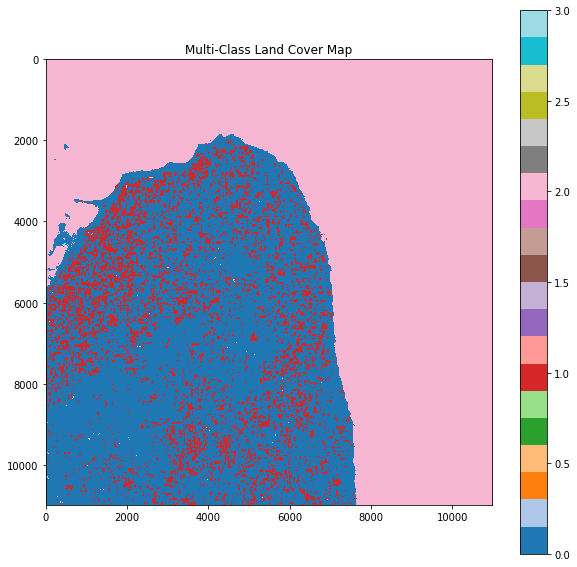

In [9]:
#Visualization
plt.figure(figsize=(10, 10))
plt.imshow(predicted_image, cmap='tab20', interpolation='nearest')
plt.title("Multi-Class Land Cover Map")
plt.colorbar()
plt.show()

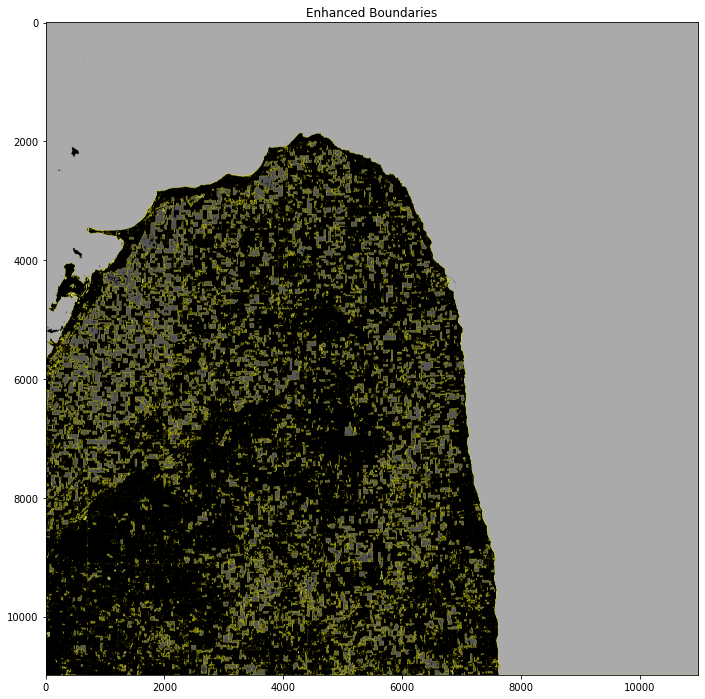

In [10]:
#Boundary Detection
contours, _ = cv2.findContours((predicted_image > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
normalized_image = cv2.normalize(predicted_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
color_image = cv2.cvtColor(normalized_image, cv2.COLOR_GRAY2BGR)
cv2.drawContours(color_image, contours, -1, (255, 255, 0), thickness=2)
plt.figure(figsize=(12, 12))
plt.imshow(color_image)
plt.title("Enhanced Boundaries")
plt.show()

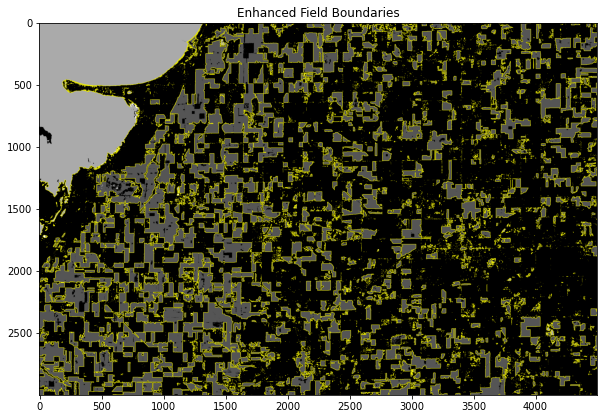

In [11]:
# Zoomed-in View of Enhanced Boundaries
x_min, x_max, y_min, y_max = 500, 5000, 3000, 6000
zoomed_image = color_image[y_min:y_max, x_min:x_max]
plt.figure(figsize=(10, 10))
plt.imshow(zoomed_image)
plt.title("Enhanced Field Boundaries")
plt.show()

In [12]:
#Image as GeoTIFF
def save_predicted_image_as_tiff(predicted_image, reference_path, output_path):
    with rasterio.open(reference_path) as ref:
        transform = ref.transform
        crs = ref.crs
        dtype = predicted_image.dtype

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=predicted_image.shape[0],
        width=predicted_image.shape[1],
        count=1,
        dtype=dtype,
        crs=crs,
        transform=transform,
    ) as dst:
        dst.write(predicted_image, 1)

output_path = "/home/mreddi/pfiles/predicted_image.tif"
save_predicted_image_as_tiff(predicted_image, file_paths["B02"], output_path)
print(f"Predicted image saved at: {output_path}")


Predicted image saved at: /home/mreddi/pfiles/predicted_image.tif


In [13]:
#IoU
def align_rasters(reference_path, target_path, resampled_output_path):
    with rasterio.open(reference_path) as ref_src:
        ref_meta = ref_src.meta
        ref_transform = ref_src.transform
        ref_crs = ref_src.crs
        ref_width = ref_src.width
        ref_height = ref_src.height

        with rasterio.open(target_path) as tgt_src:
            tgt_meta = tgt_src.meta
            resampled_data = np.empty((ref_height, ref_width), dtype=tgt_meta['dtype'])

            reproject(
                source=rasterio.band(tgt_src, 1),
                destination=resampled_data,
                src_transform=tgt_src.transform,
                src_crs=tgt_src.crs,
                dst_transform=ref_transform,
                dst_crs=ref_crs,
                resampling=Resampling.nearest
            )

            resampled_meta = ref_meta.copy()
            resampled_meta.update(dtype=tgt_meta['dtype'])
            with rasterio.open(resampled_output_path, 'w', **resampled_meta) as resampled_dst:
                resampled_dst.write(resampled_data, 1)
    return resampled_output_path

def calculate_iou(predicted_image_path, ground_truth_path):
    with rasterio.open(predicted_image_path) as pred_src:
        predicted_image = pred_src.read(1).astype(np.uint8)
    with rasterio.open(ground_truth_path) as gt_src:
        ground_truth_image = gt_src.read(1).astype(np.uint8)

    predicted_binary = (predicted_image > 0).astype(np.uint8)
    ground_truth_binary = (ground_truth_image > 0).astype(np.uint8)
    intersection = np.logical_and(predicted_binary, ground_truth_binary).sum()
    union = np.logical_or(predicted_binary, ground_truth_binary).sum()
    iou = intersection / union if union > 0 else 0
    return iou, intersection, union

# Paths
ground_truth_path = "/home/mreddi/pfiles/cdl_2022.tif"
aligned_predicted_image_path = "/home/mreddi/aligned_predicted_image.tif"
aligned_predicted_image_path = align_rasters(ground_truth_path, output_path, aligned_predicted_image_path)
iou, intersection, union = calculate_iou(aligned_predicted_image_path, ground_truth_path)

print(f"Intersection: {intersection} pixels")
print(f"Union: {union} pixels")
print(f"IoU Accuracy: {iou:.4f}")

Intersection: 622075 pixels
Union: 3345000 pixels
IoU Accuracy: 0.1860


In [14]:
#Total Acreage
pixel_size = 10  # Sentinel-2 pixel size
acre_conversion = 0.000247105
areas = [cv2.contourArea(contour) * (pixel_size ** 2) * acre_conversion for contour in contours]
total_acreage = sum(areas)
print("Total Acreage:", total_acreage, "acres")

Total Acreage: 1833974.3168309913 acres


In [15]:
# Processing Time
end_time = time.time()
processing_time = end_time - start_time
# System Resource Usage
cpu_usage = psutil.cpu_percent(interval=1)
memory_info = psutil.virtual_memory()
used_memory = memory_info.used / (1024 ** 2)  # MB
total_memory = memory_info.total / (1024 ** 2)  # MB
# Total Number of Fields Detected
num_fields_detected = len(contours)
# Print Outputs
print("Total Acreage:", total_acreage, "acres")
print("Processing Time:", processing_time, "seconds")
print("CPU Usage:", cpu_usage, "%")
print("Total Memory:", total_memory, "MB")
print("Used Memory:", used_memory, "MB")
print("Total Number of Fields Detected:", num_fields_detected)

Total Acreage: 1833974.3168309913 acres
Processing Time: 250.88659071922302 seconds
CPU Usage: 3.9 %
Total Memory: 515567.40625 MB
Used Memory: 126984.0625 MB
Total Number of Fields Detected: 78806
